## Computational Fluid Dynamics: *Towards Navier-Stokes*<sup>[1](https://lorenabarba.com/blog/cfd-python-12-steps-to-navier-stokes/)</sup>

In [1]:
# Preamble

%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

from IPython.display import HTML

import time, sys, warnings

import matplotlib as mpl
import numpy as np
import sympy as sym

from sympy import init_printing
init_printing(use_latex=True)

from sympy.utilities.lambdify import lambdify

import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter

from matplotlib.colors import ListedColormap
from matplotlib.legend_handler import HandlerTuple

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

### 1D Linear Convection / Advection


C = 0.80



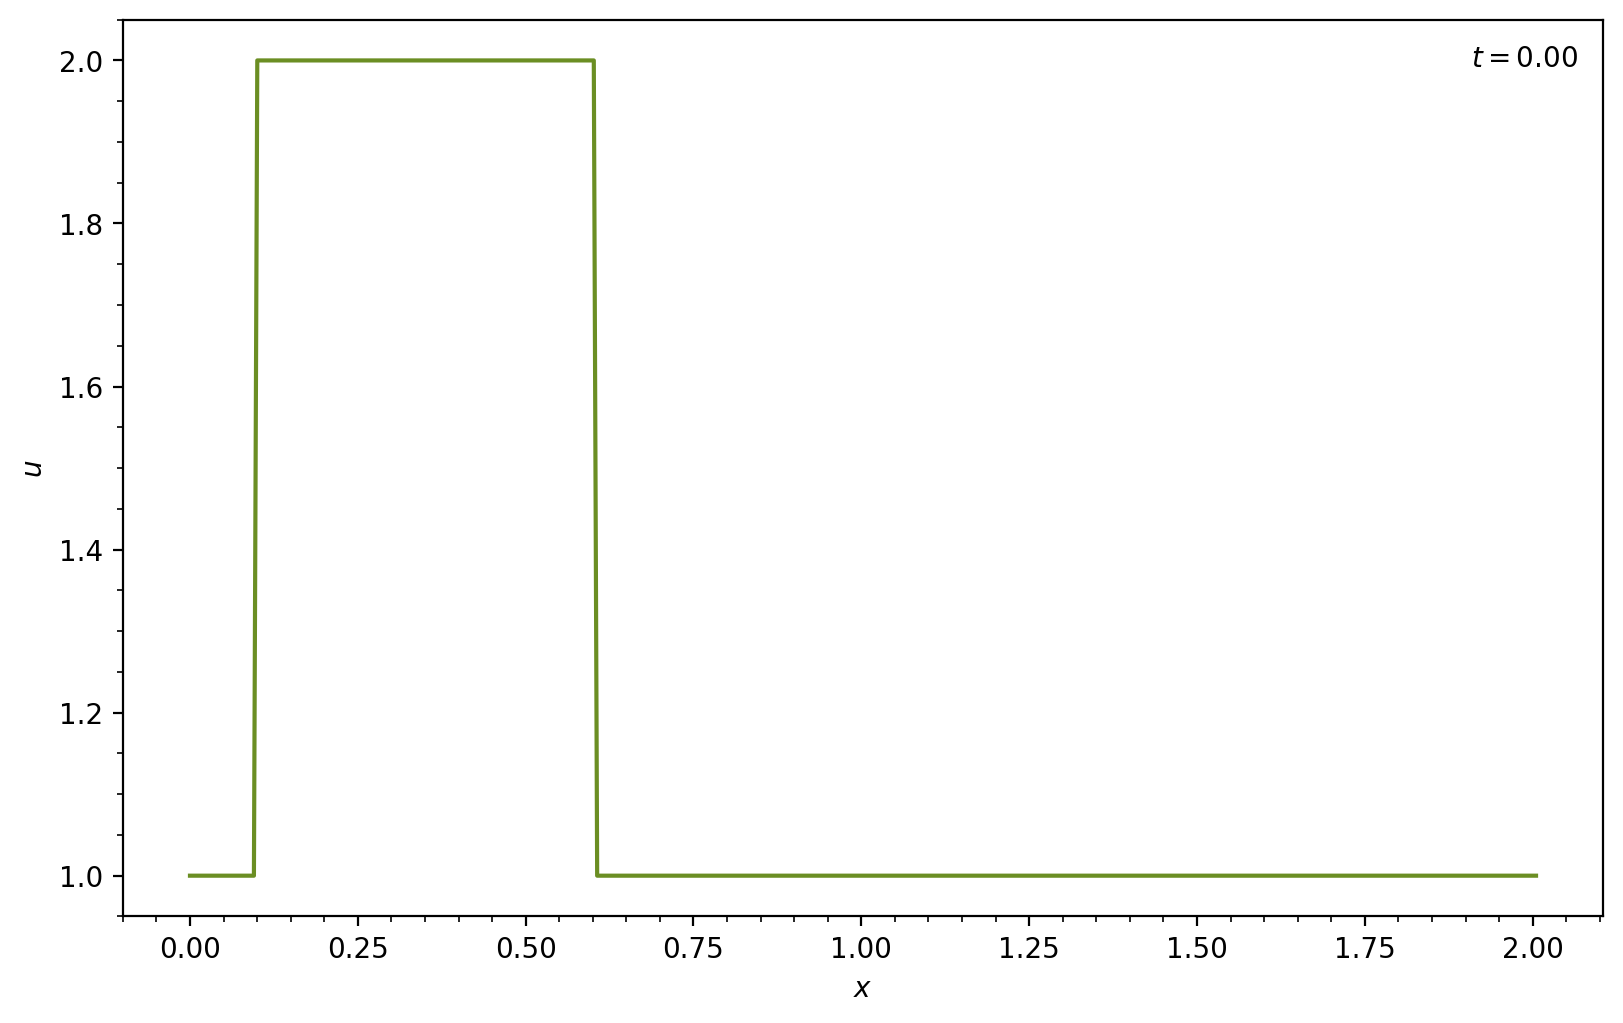

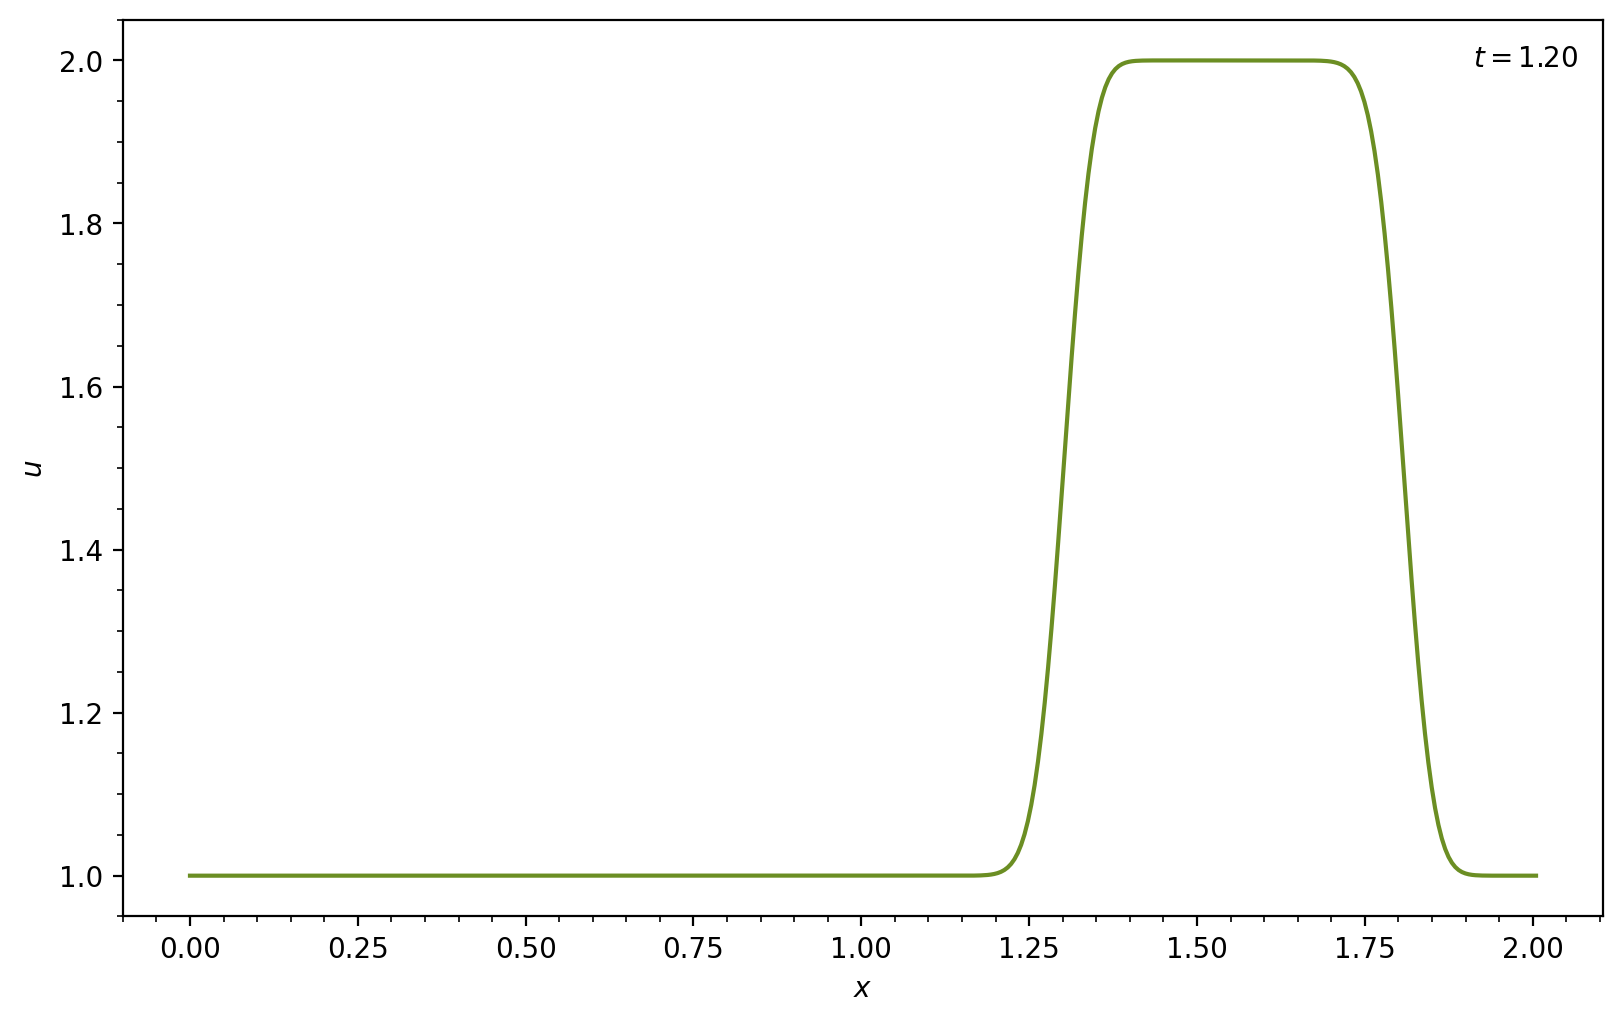

In [2]:
# Setup

nx = 401
dx = 2 / (nx - 1)

x = np.linspace(0, nx * dx, nx)

nt = 300
dt = .004

c = 1.

C = c * dt / dx

print(f'\nC = {C:.2f}\n')

u = np.ones(nx)
u[int(.1 / dx):int(.6 / dx + 1)] = 2.

# Initial

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
ylim = plt.ylim()
xlim = plt.xlim()
plt.show()
plt.close()

# Evolution

k = 5

history = [u.copy()]

for n in range(nt):
    u[1:] = u[1:] - C * (u[1:] - u [:-1])

    if n % k == 0:
        history.append(u.copy())
        
# Final

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
line, = ax.plot(x, padded_history[0])
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$u$')

def update(frame):
    line.set_ydata(padded_history[frame])
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return line, leg

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=True)

ani.save("1d_lin_conv_adv.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="1d_lin_conv_adv.gif" width="800">')

### 1D Nonlinear Convection / Advection

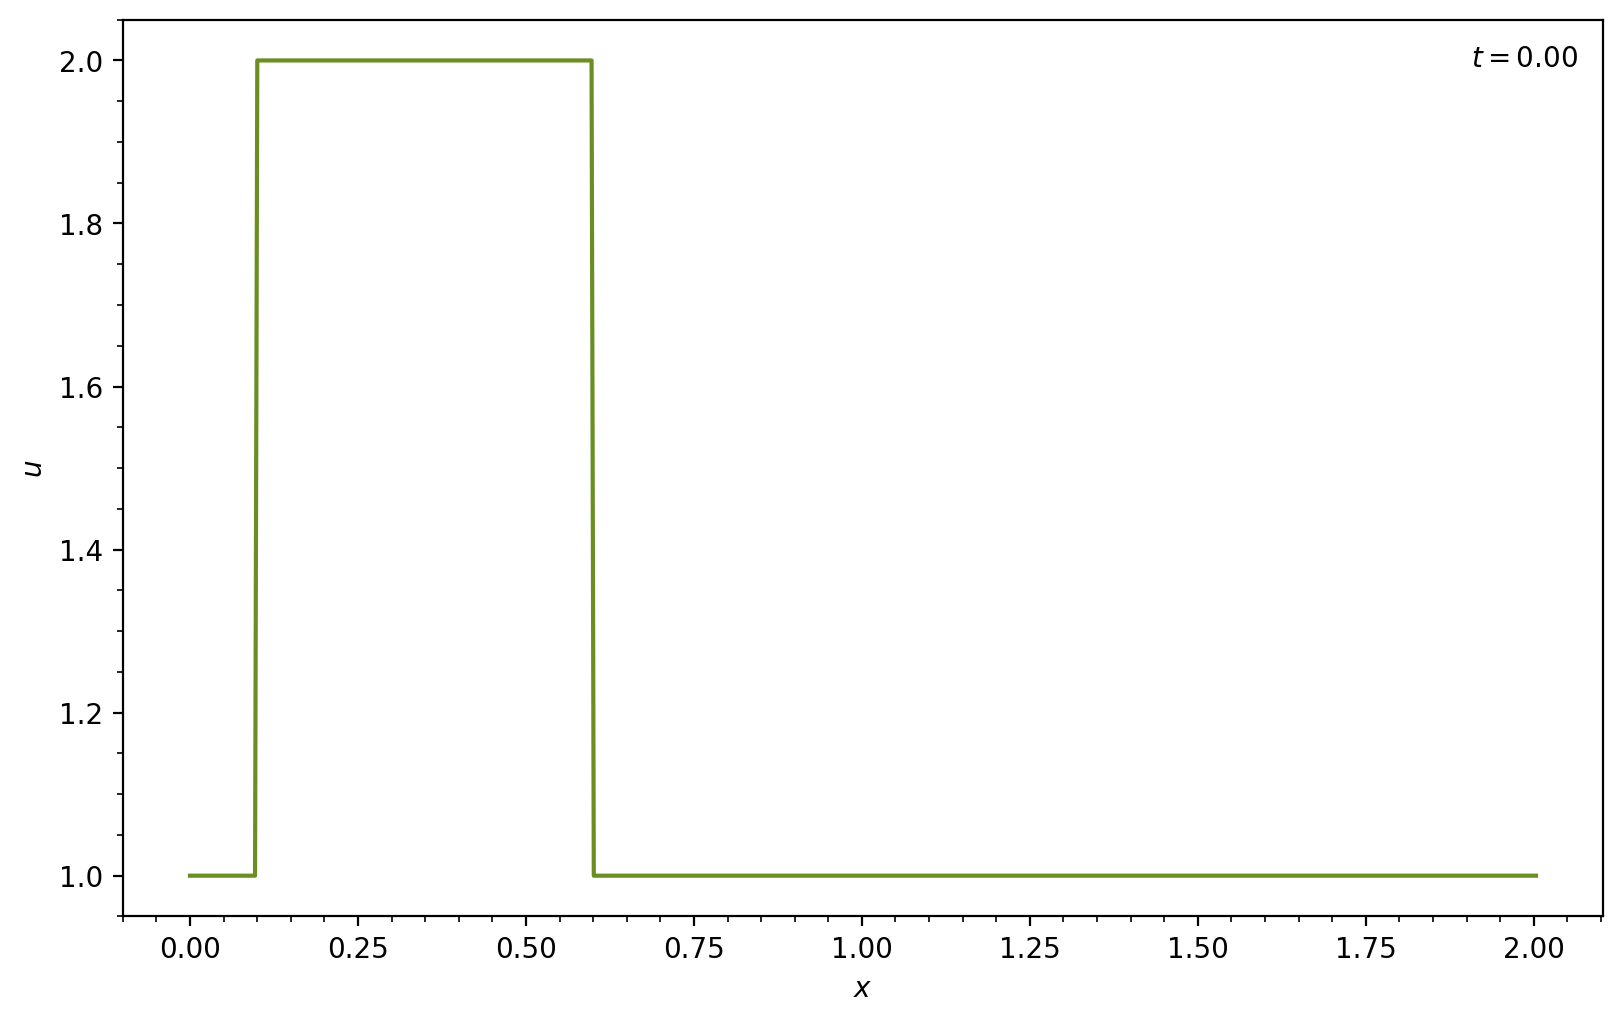

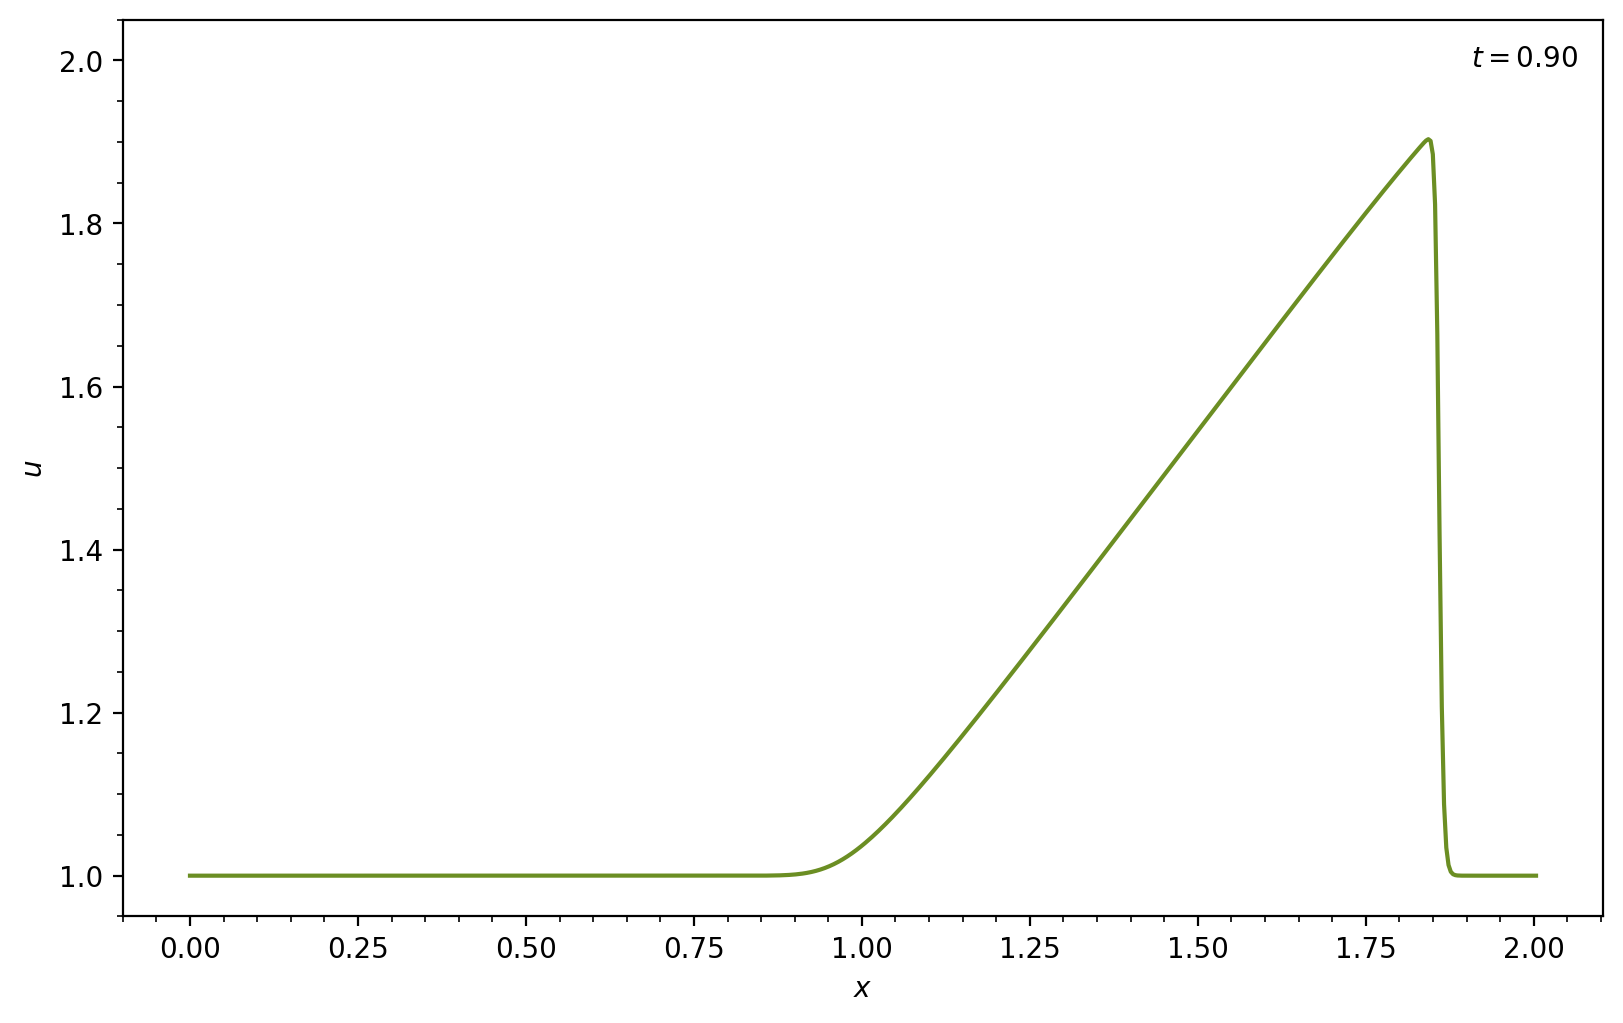

In [3]:
# Setup

nx = 601
dx = 2 / (nx - 1)

x = np.linspace(0, nx * dx, nx)

nt = 900
dt = .001

u = np.ones(nx)
u[int(.1 / dx):int(.6 / dx + 1)] = 2.

# Initial

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
ylim = plt.ylim()
xlim = plt.xlim()
plt.show()
plt.close()

# Evolution

k = 15

history = [u.copy()]

for n in range(nt):
    u[1:] = u[1:] - u[1:] * dt / dx * (u[1:] - u [:-1])

    if n % k == 0:
        history.append(u.copy())
        
# Final

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
line, = ax.plot(x, padded_history[0])
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$u$')

def update(frame):
    line.set_ydata(padded_history[frame])
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return line, leg

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=True)

ani.save("1d_nonlin_conv_adv.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="1d_nonlin_conv_adv.gif" width="800">')

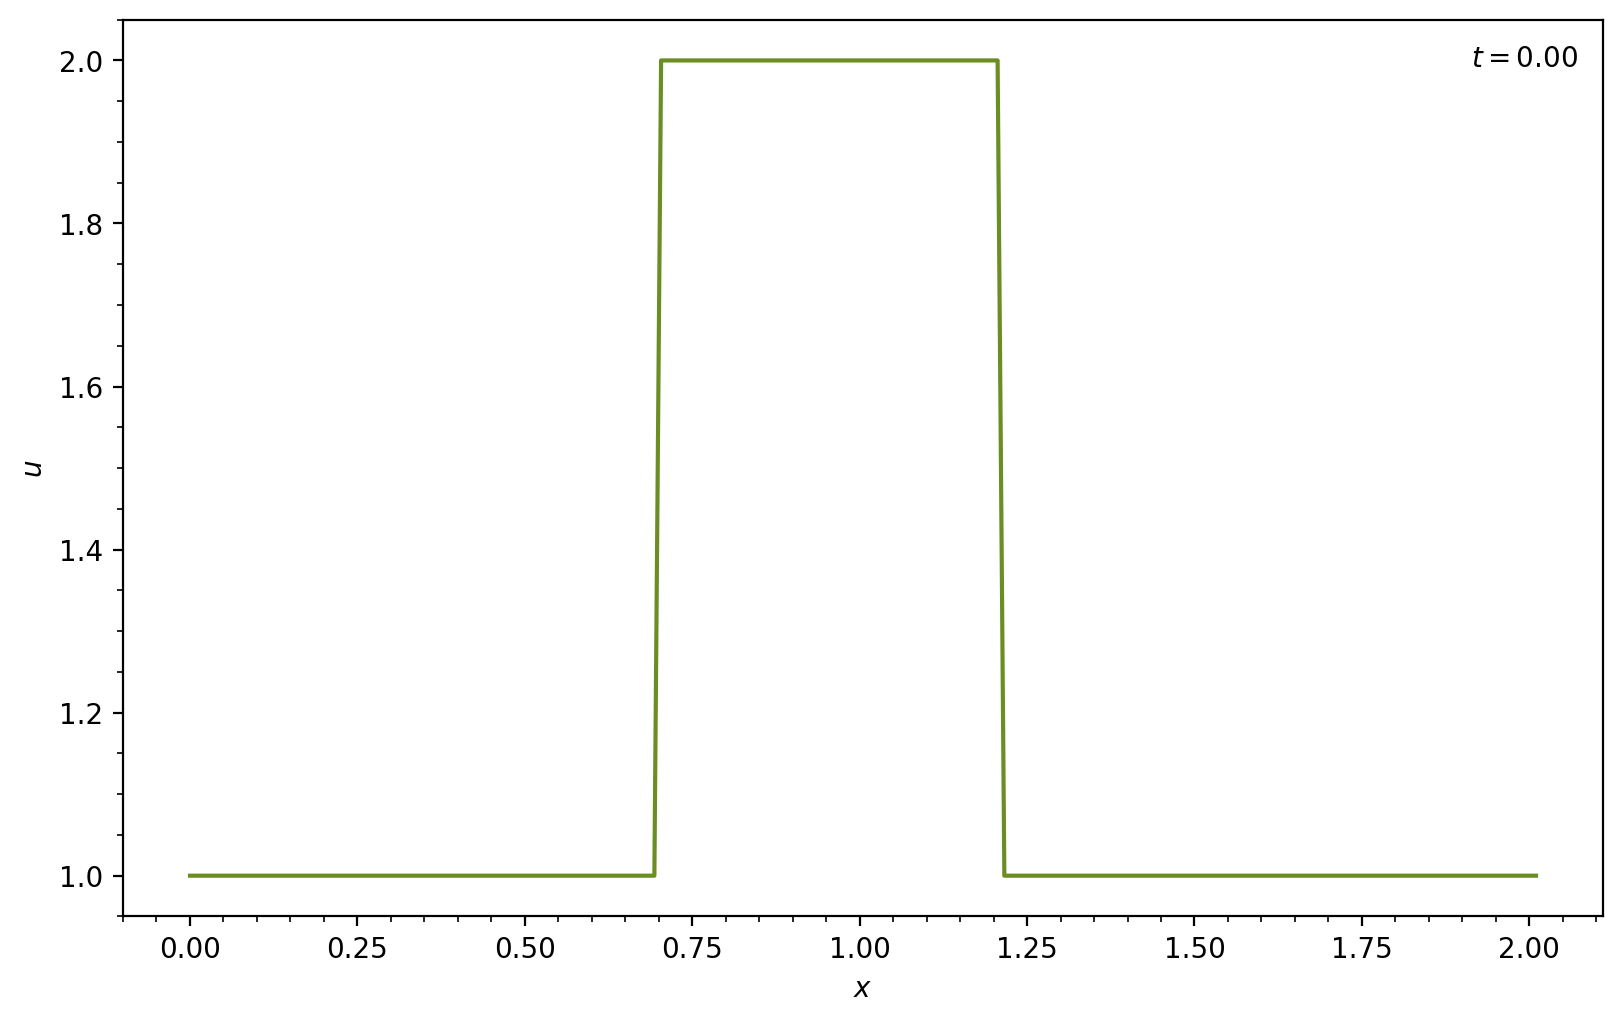

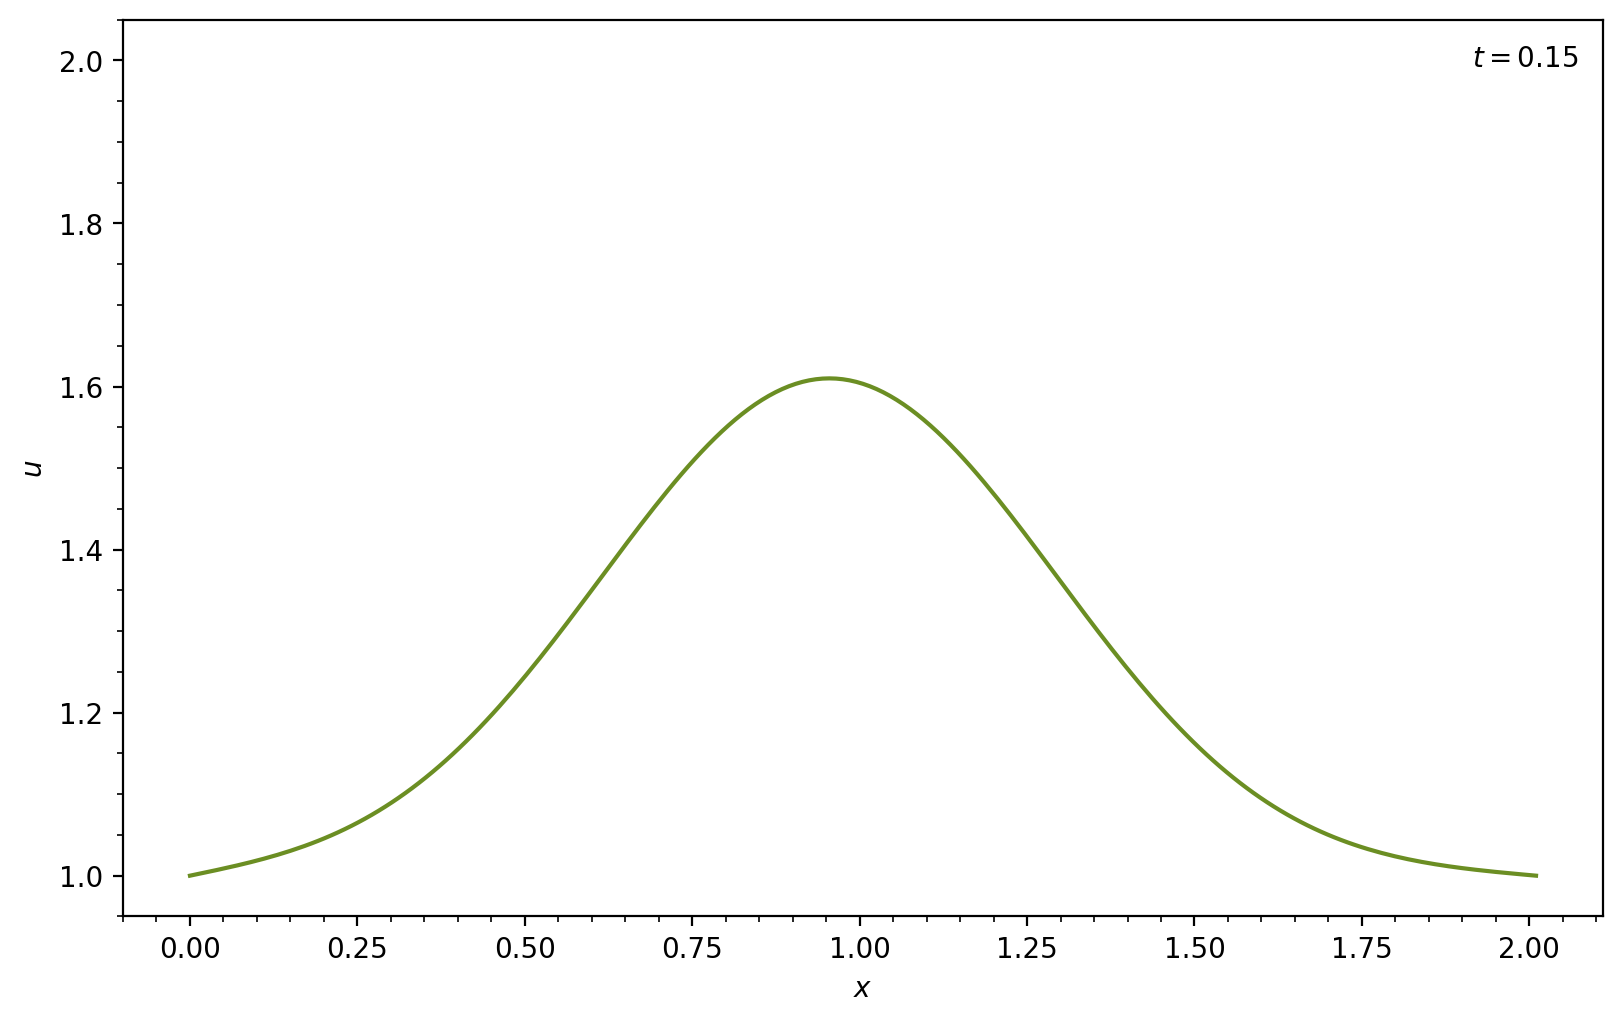

In [4]:
# Setup

nx = 201
dx = 2 / (nx - 1)

x = np.linspace(0, nx * dx, nx)

nt = 2200

nu = .3
sigma = .2

dt = sigma * dx**2 / nu

u = np.ones(nx)
u[int(.7 / dx):int(1.2 / dx + 1)] = 2.

# Initial

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
ylim = plt.ylim()
xlim = plt.xlim()
plt.show()
plt.close()

# Evolution

k = 40

history = [u.copy()]

for n in range(nt):
    u[1:-1] = u[1:-1] + nu * dt / dx**2 * (u[2:] - 2 * u[1:-1] + u[:-2])

    if n % k == 0:
        history.append(u.copy())
        
# Final

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
line, = ax.plot(x, padded_history[0])
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$u$')

def update(frame):
    line.set_ydata(padded_history[frame])
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return line, leg

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=True)

ani.save("1d_diffus.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="1d_diffus.gif" width="800">')

### 1D Bateman-Burgers Equation

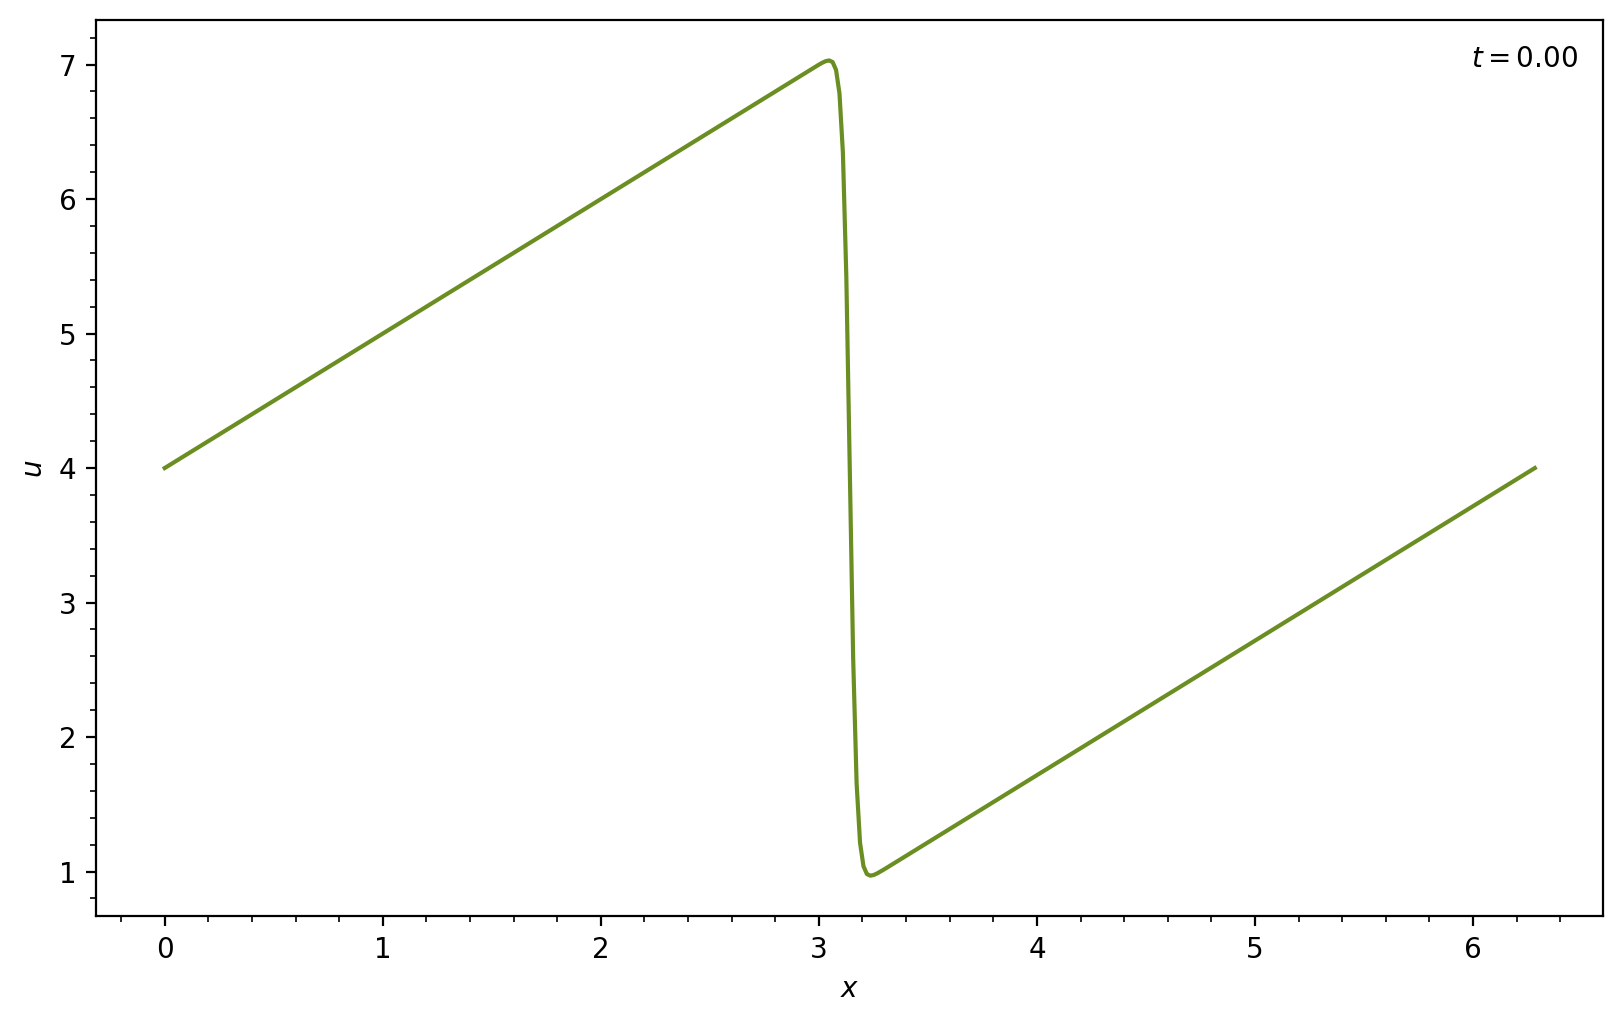

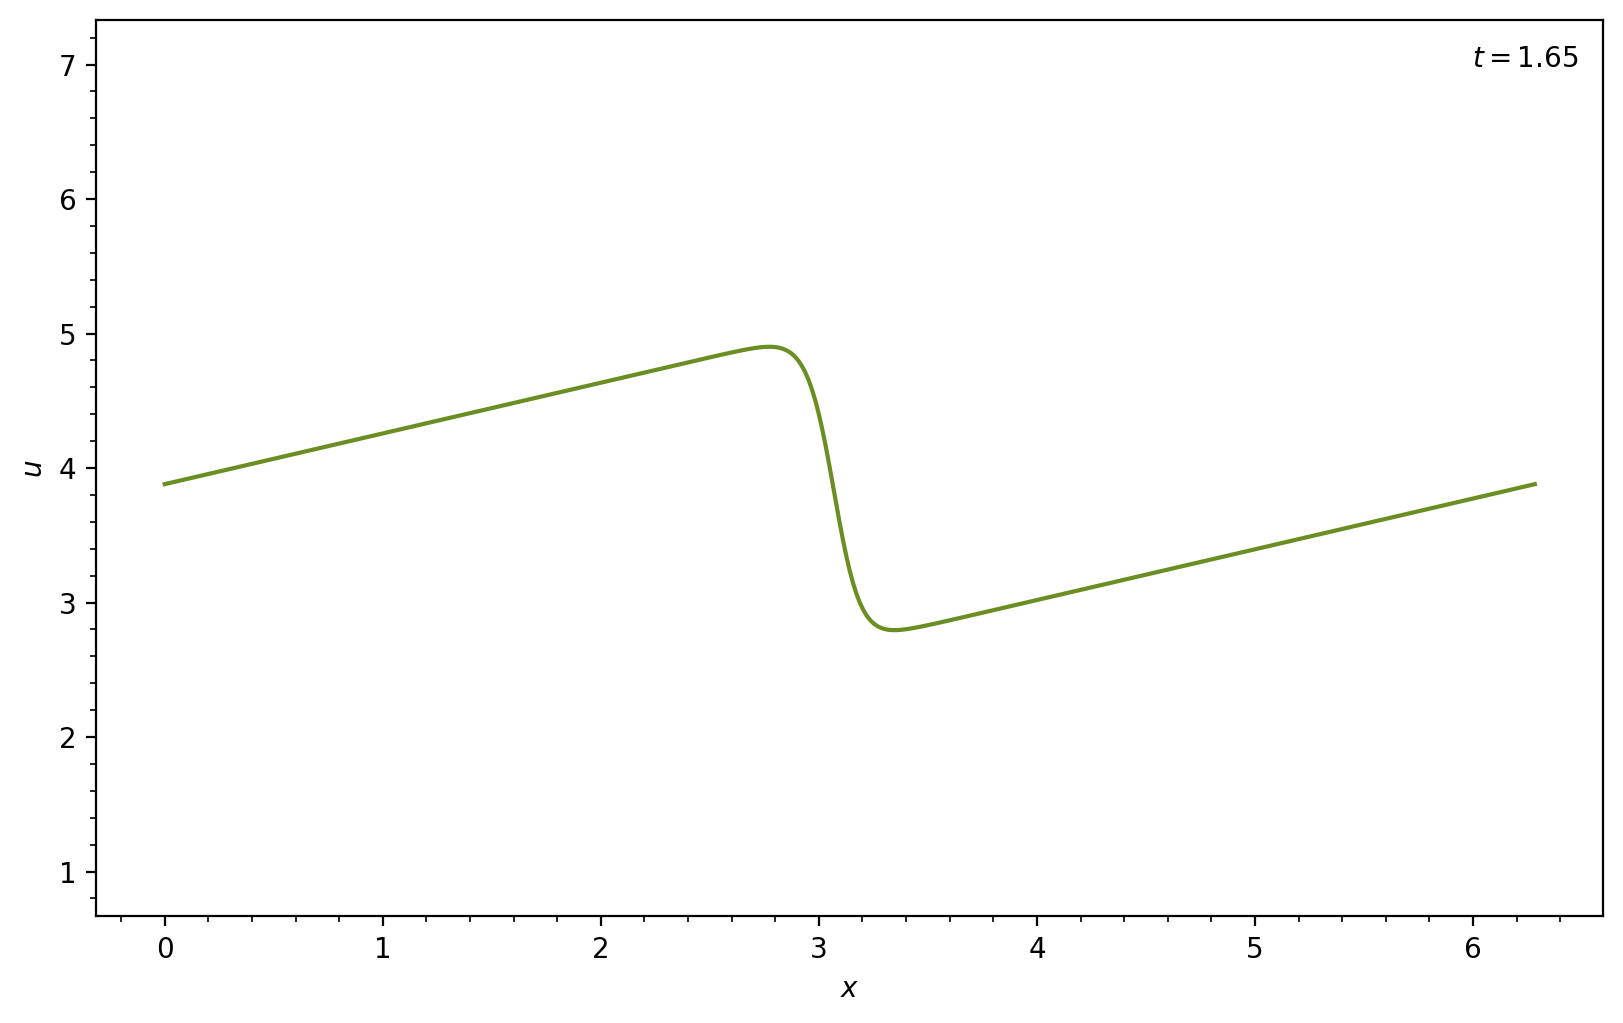

In [5]:
# Computation

x, nu, t = sym.symbols('x nu t')

phi = (sym.exp(-(x - 4 * t)**2 / (4 * nu * (t + 1))) +
       sym.exp(-(x - 4 * t - 2 * sym.pi)**2 / (4 * nu * (t + 1))))

phiprime = phi.diff(x)

u = -2 * nu * (phiprime / phi) + 4

ufunc = lambdify((t, x, nu), u)

# Setup

nx = 401
nt = 2100
dx = 2 * np.pi / (nx - 1)
nu = .05
dt = dx * nu

x = np.linspace(0, 2 * np.pi, nx)
un = np.empty(nx)
t = 0

u = np.asarray([ufunc(t, x0, nu) for x0 in x])

# Initial

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${0.:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
ylim = plt.ylim()
xlim = plt.xlim()
plt.show()
plt.close()

# Evolution

k = 20

history = [u.copy()]

for n in range(nt):
    un = u.copy()
    u[1:-1] = un[1:-1] - un[1:-1] * dt / dx * (un[1:-1] - un[:-2]) + nu * dt / dx**2 * (un[2:] - 2 * un[1:-1] + un[:-2])
    u[0] = un[0] - un[0] * dt / dx * (un[0] - un[-2]) + nu * dt / dx**2 * (un[1] - 2 * un[0] + un[-2])
    u[-1] = u[0]

    if n % k == 0:
        history.append(u.copy())
        
# Final

plt.plot(x, u)
plt.plot([], [], ' ', label=f'$t = ${nt * dt:.2f}')
plt.xlabel(r'$x$')
plt.ylabel(r'$u$')
plt.legend(loc='upper right')
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()
plt.close()

# Animation

pause_number = 20
padded_history = ([history[0]] * pause_number) + history + ([history[-1]] * pause_number)

fig, ax = plt.subplots(dpi=150)
line, = ax.plot(x, padded_history[0])
ax.plot([], [], ' ', label=f'$t = ${0.:.2f}')
leg = ax.legend(loc='upper right')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$u$')

def update(frame):
    line.set_ydata(padded_history[frame])
    display_frame = max(0, min(frame - pause_number, len(history) - 1))
    time = display_frame * k * dt
    leg.get_texts()[0].set_text(f'$t = ${time:.2f}')
    return line, leg

ani = FuncAnimation(fig, update, frames=len(padded_history), interval=50, blit=True)

ani.save("1d_bate_burg_eq.gif", writer=PillowWriter(fps=20))

plt.close()
HTML('<img src="1d_bate_burg_eq.gif" width="800">')